# 4.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish simple **benchmarks** to contextualise the results.

## Table of Contents

- [4.2.1 Data Information](#421-data-information)
- [4.2.2 Model Configurations](#422-model-configurations)
- [4.2.3 Model Definition](#423-model-definition)
- [4.2.4 Hyperparameter Search Definition (GridSearch using Optuna)](#424-hyperparameter-search-definition-gridsearch-using-optuna)
- [Evaluation & Save Utilities](#evaluation--save-utilities)
- [4.2.5 Visualization: Model Architecture](#425-visualization-model-architecture)
- [4.2.6 Train / Val / Test Split](#426-train--val--test-split)
- [4.2.7 Feature Preparation](#427-feature-preparation)
    - [Hexagon Encoding](#hexagon-encoding)
- [Feature Selection](#feature-selection)
- [4.2.8 Benchmark Models](#428-benchmark-models)
- [Embed Dimension Search](#embed-dimension-search)
- [4.2.9 Baseline Model — Training](#429-baseline-model--training)
  - [4.2.9 Baseline Model — Evaluation](#429-baseline-model--evaluation)
- [4.2.10 Hyperparameter Search — Baseline Model](#4210-hyperparameter-search--baseline-model)
  - [4.2.10 Tuned Baseline — Training](#4210-tuned-baseline--training)
  - [4.2.10 Tuned Baseline — Evaluation](#4210-tuned-baseline--evaluation)
- [4.2.11 Deeper Model — Training](#4211-deeper-model--training)
  - [4.2.11 Deeper Model — Evaluation](#4211-deeper-model--evaluation)
- [4.2.12 Hyperparameter Search — Deeper Model](#4212-hyperparameter-search--deeper-model)
  - [4.2.12 Tuned Deeper — Training](#4212-tuned-deeper--training)
  - [4.2.12 Tuned Deeper — Evaluation](#4212-tuned-deeper--evaluation)
- [4.2.13 Wider Model — Training](#4213-wider-model--training)
  - [4.2.13 Wider Model — Evaluation](#4213-wider-model--evaluation)
- [4.2.14 Hyperparameter Search — Wider Model](#4214-hyperparameter-search--wider-model)
  - [4.2.14 Tuned Wider — Training](#4214-tuned-wider--training)
  - [4.2.14 Tuned Wider — Evaluation](#4214-tuned-wider--evaluation)
- [4.2.15 Visualization: Architecture Comparison](#4215-visualization-architecture-comparison)
  - [Learning Curves](#learning-curves)
  - [Statistical Significance — Wilcoxon Signed-Rank](#statistical-significance--wilcoxon-signed-rank)


In [1]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #


import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import datetime

# visualization
from torchinfo import summary
import matplotlib.pyplot as plt

# reset working dir
import os
from pathlib import Path


In [2]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/hexagon/demand_hex_24h_low.parquet")

In [4]:
data

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,862664197ffffff,residential,16,15,38.076923,1170.437500,10.839375,28.593750,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.000000,0.000000,0.027498,0.659954
1,2025-01-01,482136,86266419fffffff,residential,1,1,45.000000,1380.000000,8.800000,25.250000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.000000,0.000000,0.027521,0.330253
2,2025-01-01,482136,8626641b7ffffff,residential,6,6,22.500000,1425.666667,10.806667,28.458333,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.000000,0.000000,0.000000,0.302173
3,2025-01-01,482136,862664527ffffff,airport,265,134,87.305389,1445.781132,12.467358,33.056604,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.000000,0.000000,0.000000,0.961182
4,2025-01-01,482136,86266452fffffff,residential,2,2,0.000000,2130.000000,17.800000,44.750000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.054970,0.027485,0.027485,1.346772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12040,2025-12-31,490872,862664dafffffff,residential,5,5,30.000000,1365.000000,7.588000,22.774000,...,3.960234,4.291273,0.000000,0.027329,0.000000,0.000000,0.000000,0.000000,0.000000,0.027329
12041,2025-12-31,490872,862759347ffffff,airport,611,462,122.920792,2086.099836,14.661211,38.723142,...,2.892475,2.057285,0.136860,1.176998,0.301092,0.520069,0.000000,0.000000,0.027372,2.162392
12042,2025-12-31,490872,86275934fffffff,airport,612,449,128.810241,2002.815359,14.596144,38.289804,...,1.220338,2.809967,0.191761,1.068385,0.465706,0.383523,0.000000,0.000000,0.027394,2.136770
12043,2025-12-31,490872,86275935fffffff,airport,175,159,132.580645,2085.954286,14.708171,38.737771,...,1.340206,7.539746,0.054799,0.273996,0.054799,0.027400,0.000000,0.000000,0.000000,0.410994


## 4.2.1 Data Information

In [5]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

hex_row_counts = data.groupby('pickup_h3_res6').size()

print(f"\n--- Rows per hexagon (daily buckets) ---")
print(f"Unique hexagons           : {len(hex_row_counts):>8,}")
print(f"Avg daily buckets per hex : {hex_row_counts.mean():>8.1f}")
print(f"Min daily buckets per hex : {hex_row_counts.min():>8,}")
print(f"Max daily buckets per hex : {hex_row_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :     12,045
Unique combinations (no time) :     12,045
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :   12,045 combinations

--- Rows per hexagon (daily buckets) ---
Unique hexagons           :       33
Avg daily buckets per hex :    365.0
Min daily buckets per hex :      365
Max daily buckets per hex :      365

--- Demand ---
Zero-demand rows               :      848  (7.0%)
Non-zero-demand rows           :   11,197  (93.0%)


In [6]:
data.head()

,time_bucket,bucket_index,pickup_h3_res6,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,862664197ffffff,residential,16,15,38.076923,1170.437500,10.839375,28.593750,...,3.463863,5.190882,0.000000,0.412471,0.219985,0.000000,0.00000,0.000000,0.027498,0.659954
1,2025-01-01,482136,86266419fffffff,residential,1,1,45.000000,1380.000000,8.800000,25.250000,...,0.770790,5.836479,0.055042,0.137605,0.055042,0.055042,0.00000,0.000000,0.027521,0.330253
2,2025-01-01,482136,8626641b7ffffff,residential,6,6,22.500000,1425.666667,10.806667,28.458333,...,3.428506,4.626667,0.027470,0.247232,0.027470,0.000000,0.00000,0.000000,0.000000,0.302173
3,2025-01-01,482136,862664527ffffff,airport,265,134,87.305389,1445.781132,12.467358,33.056604,...,2.529989,4.162891,0.027462,0.631634,0.302086,0.000000,0.00000,0.000000,0.000000,0.961182
4,2025-01-01,482136,86266452fffffff,residential,2,2,0.000000,2130.000000,17.800000,44.750000,...,2.695998,5.548927,0.054970,0.659643,0.137426,0.384792,0.05497,0.027485,0.027485,1.346772


## 4.2.2 Model Configurations

In [7]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# initial values
OPTIMIZER          = "sgd"
LEARNING_RATE      = 5e-5
WEIGHT_DECAY       = 0.0
BATCH_SIZE         = 1024
MAX_EPOCHS         = 300

# training loss
LOSS               = "mae"  # mse | mae | poisson_nll | nb_nll
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus" # force positive outputs

# activation function
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# early stopping model training
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

# embedded layer for hexagons
HEX_EMBED_DIM      = 16

device = "cuda" if torch.cuda.is_available() else "cpu"

# inrastructure for multiple seeds, currently only one seed to save computation time
SEEDS              = (0,)

# model architectures
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    WEIGHT_DECAY   = WEIGHT_DECAY,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    HEX_EMBED_DIM  = HEX_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

# hyperparameter search
HP_SEARCH_SEEDS        = SEEDS
HP_PATIENCE            = 5
BEST_HP                = {}

HP_LR_DECADES  = [2e-5, 5e-5, 8e-5, 2e-4, 5e-4, 8e-4, 2e-3, 5e-3, 8e-3, 2e-2, 5e-2, 8e-2]
HP_WD_DECADES  = [0.0, 5e-4, 5e-3, 5e-2]
HP_FINE_STEPS  = list(range(1, 10))


## 4.2.3 Model Definition

In [8]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """
    NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta).
    """
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_hex, embed_dim):
        super().__init__()
        self.hex_embed = nn.Embedding(n_hex, embed_dim)
        nn.init.normal_(self.hex_embed.weight, std=0.01)

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, hex_idx):
        emb = self.hex_embed(hex_idx)          # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)      # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None, epoch_cb=None, test_data=None):
    if seed is not None:
        set_seed(seed)
    n_layers, width = arch
    _embed_dim  = embed_dim  if embed_dim  is not None else config.HEX_EMBED_DIM
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_HEX, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train,   dtype=torch.float32),
            torch.as_tensor(hex_train, dtype=torch.long),
            torch.as_tensor(y_train,   dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t   = torch.as_tensor(X_val,   dtype=torch.float32).to(device)
    hex_val_t = torch.as_tensor(hex_val, dtype=torch.long).to(device)
    y_val_t   = torch.as_tensor(y_val,   dtype=torch.float32).to(device)
    if test_data is not None:   # optional (X, y, group) on the training scale — monitoring only
        X_test_t = torch.as_tensor(test_data[0], dtype=torch.float32).to(device)
        y_test_t = torch.as_tensor(test_data[1], dtype=torch.float32).to(device)
        g_test_t = torch.as_tensor(test_data[2], dtype=torch.long).to(device)
    history = {"train": [], "val": [], "test": []}

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, hb, yb in train_dl:
            xb, hb, yb = xb.to(device), hb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, hb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, hex_val_t), y_val_t).item()
            if test_data is not None:
                history["test"].append(loss_fn(model(X_test_t, g_test_t), y_test_t).item())
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        if epoch_cb is not None:
            epoch_cb(epoch, val_loss)   # hp-search hook; may raise to abort the run

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    model.history = history   # per-epoch losses for the learning-curve plots
    return model, best_val, best_train_loss


## 4.2.4 Hyperparameter Search Definition (GridSearch using Optuna)

Two-step search→fine grid search (Optuna `GridSampler`):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, three representative values
   per decade to locate the best decade of the learning rate for the finer hyperparameter search.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade from step 1.
    - e.g. decade step 1 identified 1e-3 to be the best decade, then [1e-3, 2e-3, ..., 9e-3] are evaluated to find the best LR.

This way only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result.

In [9]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility (Optuna GridSampler)  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  hex_train, hex_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None):
    """
    Optuna grid search (GridSampler) over lr and weight decay.

    Every lr × wd combination from the candidate lists is evaluated
    once (grid search); the median pruner aborts
    combinations whose validation loss is clearly worse than the running
    median. Each trial trains one model and is scored by the mean validation
    loss.
    """
    lr_candidates = lr_candidates or HP_LR_DECADES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_DECADES
    arch_label    = ARCH_NAMES.get(arch, str(arch))
    search_space  = {'lr': list(lr_candidates), 'weight_decay': list(wd_candidates)}
    n_trials      = len(lr_candidates) * len(wd_candidates)

    def objective(trial):
        lr = trial.suggest_categorical('lr', lr_candidates)
        wd = trial.suggest_categorical('weight_decay', wd_candidates)

        def epoch_cb(epoch, val_loss):
            # pruning
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        val_losses = []
        for j, seed in enumerate(HP_SEARCH_SEEDS):
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                hex_train, hex_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
                epoch_cb=epoch_cb if j == 0 else None,
            )
            val_losses.append(val_loss)
        return float(np.mean(val_losses))

    print(f'HP Search — {arch_label}  |  grid {len(lr_candidates)}×{len(wd_candidates)}'
          f' = {n_trials} combos  |  seeds={HP_SEARCH_SEEDS}  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>10}  {'wd':>10}  {'mean val':>10}  state")
    print('-' * 50)

    def log_trial(study, trial):
        wd  = trial.params.get('weight_decay', 0.0)
        val = trial.value if trial.value is not None else float('nan')
        print(f"{trial.number + 1:>4}  {trial.params['lr']:>10.2e}  {wd:>10.2e}"
              f"  {val:>10.4f}  {trial.state.name.lower()}")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.GridSampler(search_space, seed=HP_SEARCH_SEEDS[0]),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

    complete = [t for t in study.trials
                if t.state == optuna.trial.TrialState.COMPLETE]
    print('\n--- Top 5 ---')
    for t in sorted(complete, key=lambda t: t.value)[:5]:
        print(f"  lr={t.params['lr']:.2e}"
              f"  wd={t.params.get('weight_decay', 0.0):.2e}"
              f"  val_loss={t.value:.4f}")

    p = study.best_trial.params
    BEST_HP[arch] = {'lr': float(p['lr']),
                     'weight_decay': float(p.get('weight_decay', 0.0))}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


def fine_candidates(best, steps=None):
    """
    Fine grid inside the decade of `best`, e.g. 5e-4 -> [1e-4, 2e-4, ..., 9e-4].
    """
    if best == 0.0:
        return [0.0]
    steps = steps or HP_FINE_STEPS
    decade = 10.0 ** int(np.floor(np.log10(best)))
    return [float(f'{s * decade:.0e}') for s in steps]


def run_hp_search_2step(arch, X_train, y_train, X_val, y_val,
                        hex_train, hex_val, device='cpu',
                        lr_decades=None, wd_decades=None):
    """
    Coarse-to-fine grid search: step 1 locates the best order of magnitude
    for lr and weight decay on a decade grid, step 2 runs a finer grid
    restricted to the winning decades.
    """
    lr_decades = lr_decades or HP_LR_DECADES
    wd_decades = wd_decades if wd_decades is not None else HP_WD_DECADES
    arch_label = ARCH_NAMES.get(arch, str(arch))

    print(f'--- Step 1/2 — decade grid ({arch_label}) ---\n')
    coarse = run_hp_search(arch, X_train, y_train, X_val, y_val,
                           hex_train, hex_val, device=device,
                           lr_candidates=lr_decades, wd_candidates=wd_decades)

    # keep the coarse winners in the fine grid so step 2 can never end up worse
    lr_fine = sorted(set(fine_candidates(coarse['lr']) + [coarse['lr']]))
    wd_fine = sorted(set(fine_candidates(coarse['weight_decay']) + [coarse['weight_decay']]))
    print(f'\n--- Step 2/2 — fine grid in winning decades ({arch_label}) ---')
    print(f'lr candidates: {lr_fine}')
    print(f'wd candidates: {wd_fine}\n')
    # overwrites BEST_HP[arch] with the fine-grid winner
    return run_hp_search(arch, X_train, y_train, X_val, y_val,
                         hex_train, hex_val, device=device,
                         lr_candidates=lr_fine, wd_candidates=wd_fine)


## Evaluation & Save Utilities
Shared helpers functions: `evaluate_models` computes the test-set metrics for the models and returns the result rows, `save_results` appends them to the results CSV.

In [10]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test, hex_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
    hex_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    mape_scores = []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t, hex_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
        nz    = y_test > 0
        mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        mape_scores.append(mape)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        # test loss under the training criterion, so train/val/test are comparable
        _y_target = y_test if IS_POISSON else y_test_log
        if config.LOSS == "mae":
            _test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
        elif config.LOSS == "mse":
            _test_loss = float(np.mean((preds_raw - _y_target) ** 2))
        elif config.LOSS == "poisson_nll":
            _test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
        else:  # nb_nll — evaluate with the model's trained dispersion
            _test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                           torch.as_tensor(_y_target, dtype=torch.float32),
                                           model.log_theta.detach().cpu()))
        test_losses.append(_test_loss)

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "mape"              : round(mape,     6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"{label}  MAPE  : {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%  (non-zero actuals only)")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check ({config.LOSS}, {'raw counts' if IS_POISSON else 'log1p scale'}) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [11]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_hex_6_24h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 4.2.5 Visualization: Model Architecture

The example row below is a real record from the dataset (hexagon `862664cc7ffffff`, 2025-01-11,
283 trips); only the embedding weights are illustrative.

```
One row of raw data  —  one hexagon on one day (24 h bucket)
┌───────────────────┬───────────────────────────────────┬─────────────┐
│  pickup_h3_res6   │  is_weekend, month_sin, area_km2, │ trip_count  │
│ '862664cc7ffffff' │      1,        0.50,     36.4, …  │     283     │
└─────────┬─────────┴─────────────────┬─────────────────┴──────┬──────┘
          │                           │                        │
          ▼                           ▼                        ▼
      hex_vocab                StandardScaler             np.log1p(y)
  '862664cc7ffffff'        [1.59, 0.40, -0.51, …]            5.65
        → 17               (18 dims, fit on train)     (training target)
          │                           │
          ▼                           │
 Embedding table                      │
 (34 rows × HEX_EMBED_DIM)            │
 row 17: [0.12, -0.31, …]             │
          │                           │
          └─────────────┬─────────────┘
                        ▼
                torch.cat(x, emb)
         [0.12, -0.31, …, 1.59, 0.40, …]
            (HEX_EMBED_DIM + 18 dims)
                        │
                        ▼
         ┌─────────────────────────────┐
         │  Linear(dim → 64)           │
         │  ReLU                       │   ← 2 blocks × 64   (baseline)
         │  Linear(64 → 64)            │      2 blocks × 256 (wider)
         │  ReLU                       │      8 blocks × 64  (deeper)
         │  Linear(64 → 1)             │
         │  Softplus                   │   ← keeps the log1p output ≥ 0
         └─────────────────────────────┘
                        │
                        ▼
        ŷ_log   (predicted log1p demand)
                        │
                        ▼  np.expm1(ŷ_log) ← evaluation only, never in the loss
         ŷ   (predicted trip count, ≥ 0)
```

**Target scale.** The network is trained on `log1p(trip_count)`, so both the `Softplus` output and
the training criterion (`config.LOSS = "mae"`) live on the log1p scale — `Softplus` is what keeps
the back-transformed prediction non-negative. Raw trip counts reappear only at evaluation time,
where `expm1` inverts the transform before evaluation metrics are computed.

**Hexagon embedding.** The table holds one row per hexagon seen in training
plus one reserved *unknown* row for hexagons that appear only in val/test. It
starts with near-zero weights and is updated by backprop alongside all other parameters, so the
network learns which hexagons behave similarly. `HEX_EMBED_DIM` is not fixed upfront: the embed
dimension search below selects it from `[8, 16, 32]`.

## 4.2.6 Train / Val / Test Split

We split rows chronologically into **70 % train / 15 % val / 15 % test** using
`train_test_split`.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [12]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 chronological split
train_data, temp_data = train_test_split(data, test_size=0.30, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :     8,431 rows
Val   :     1,807 rows
Test  :     1,807 rows


## 4.2.7 Feature Preparation

Drop leakage columns (trip-derived aggregates from the same time-bucket),
ID/index columns, categorical columns not yet encoded, and the target.  
Fit a `StandardScaler` on the **training set only** to avoid leakage into val/test.

We split the features into LEAKAGE, CYCLIC, ID and TARGET columns to have a better overview of how the FEATURE columns are composed. All three column types: LEAKAGE, RAW_CYCLIC, ID are removed since they are not relevant for our models.
- LEAKAGE contain the columns that need to be removed, either because they leak undesired information into our models (e.g. idle_time, avg_tip etc.), or because they do not add any informational value or even harm the model
- RAW_CYCLIC are the raw temporal columns that have not been transformed (transformed columns are included in FEATURE column)
- ID contains columns we need to remove, e.g. bucket_index or pickup_h3_res6


#### Hexagon Encoding

Hexagon identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network.

In [13]:
LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_h3_res6']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]


## Feature Selection

We base our decision of feature selection on two selection methods:

1. correlation matrix
2. model-based feature importance

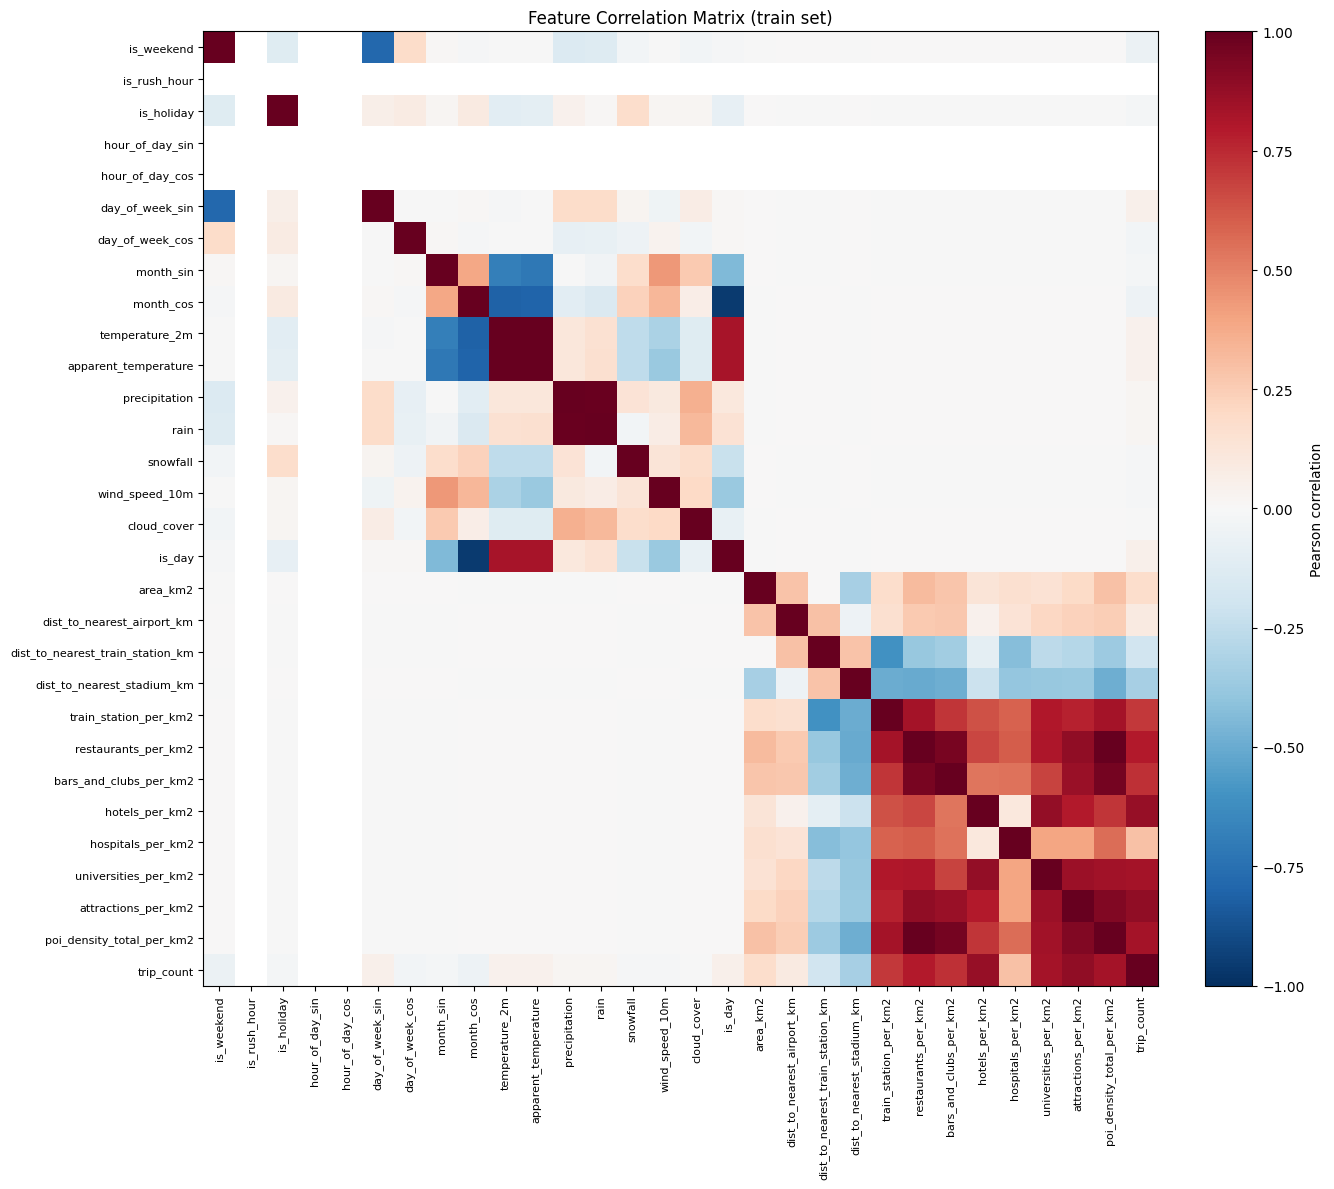

Feature pairs with |correlation| >= 0.8:
  temperature_2m                      vs apparent_temperature                 r=+0.996
  restaurants_per_km2                 vs poi_density_total_per_km2            r=+0.995
  precipitation                       vs rain                                 r=+0.986
  bars_and_clubs_per_km2              vs poi_density_total_per_km2            r=+0.956
  month_cos                           vs is_day                               r=-0.955
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.952
  attractions_per_km2                 vs poi_density_total_per_km2            r=+0.925
  restaurants_per_km2                 vs attractions_per_km2                  r=+0.888
  attractions_per_km2                 vs trip_count                           r=+0.883
  hotels_per_km2                      vs universities_per_km2                 r=+0.876
  hotels_per_km2                      vs trip_count                           r=+0.870
  

In [14]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [15]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
       poi_density_total_per_km2       0.193262         0.120983             0.001915
      dist_to_nearest_airport_km       0.034929         0.066373             0.000885
           train_station_per_km2       0.117447         0.064258             0.001150
             restaurants_per_km2       0.138991         0.058927             0.001088
             attractions_per_km2       0.138699         0.056332             0.000976
          bars_and_clubs_per_km2       0.070067         0.040846             0.000595
                 day_of_week_sin       0.022964         0.033646             0.002750
                  hotels_per_km2       0.106334         0.027372             0.000567
            universities_per_km2       0.102849         0.024989             0.000545
                      is_weekend       0.013240         0.014547             0.001501
                       month_cos       0.009499       

### **Final drop list**

- `is_rush_hour`
- `hour_of_day_sin`
- `hour_of_day_cos`
- `temperature_2m`
- `apparent_temperature`
- `rain`
- `precipitation`
- `wind_speed_10m`
- `cloud_cover`
- `snowfall`
- `is_day`
- `train_station_per_km2`
- `restaurants_per_km2`
- `attractions_per_km2`
- `bars_and_clubs_per_km2`
- `universities_per_km2`

#### **Retained**

- Temporal: `is_weekend`, `is_holiday`, `day_of_week_sin`, `day_of_week_cos`, `month_sin`, `month_cos`
- Distance: `dist_to_nearest_airport_km`, `dist_to_nearest_train_station_km`, `dist_to_nearest_stadium_km`
- POI density: `poi_density_total_per_km2`, `hotels_per_km2`, `hospitals_per_km2`
- Area: `area_km2`

#### **Cyclic hour encoding**

- `hour_of_day_sin`, `hour_of_day_cos` are the strongest predictors at fine resolution (permutation importance ≈ 0.47 / 0.24 at 1h), so they are kept for every resolution. At 24h there is exactly one row per hexagon per day, so they are constant — inert after scaling — but retained so the feature space is identical across resolutions.
- `is_rush_hour` — dropped: weak (perm ≈ 0.003) and r=−0.82 with `hour_of_day_sin`, i.e. redundant with the cyclic encoding; constant at 24h.

#### **Weather (dropped as a block)**

- Manual testing showed removing weather improved results across the board, and the model-based importances agree (permutation importance ≈ 0.0002 – 0.007). `temperature_2m`/`apparent_temperature` (r=0.99) and `rain`/`precipitation` (r=0.99) are additionally mutually redundant.

#### **Season proxy**

- `is_day` — r=−0.96 with `month_cos` (and with `hour_of_day_cos` at sub-daily resolution); a daylight/season proxy, dropped in favour of the direct cyclic encodings.

#### **POI density cluster (r ≥ 0.8)**

- The density columns are mutually collinear (`restaurants` r=0.99 with `poi_density_total`, `bars_and_clubs` 0.96, `attractions` 0.92, `universities` 0.84, `train_station` 0.83). For hexagons `poi_density_total_per_km2` is the single strongest POI signal (permutation importance ≈ 0.12, top of the POI group), so we resolve the cluster by keeping the aggregate:
    - Keep `poi_density_total_per_km2` and `hotels_per_km2` (not collinear with the total — only paired with `universities` at r=0.88)
    - Drop the components collinear with the kept total: `train_station_per_km2`, `restaurants_per_km2`, `attractions_per_km2`, `bars_and_clubs_per_km2`, and `universities_per_km2`
    - `hospitals_per_km2` is not in any r ≥ 0.8 pair, so it is retained as an independent density signal
    - Note: RF importance is split across the correlated group anyway (impurity importance dilutes across collinear features), so an individual component's rank is not evidence it is uniquely informative

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Selection.                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]

# features that we want to drop
DROP_COLS = [
    'is_rush_hour', 'hour_of_day_sin', 'hour_of_day_cos',
    'temperature_2m', 'apparent_temperature',
    'rain', 'precipitation',
    'wind_speed_10m', 'cloud_cover', 'snowfall',
    'is_day',
    'train_station_per_km2',
    'restaurants_per_km2',
    'attractions_per_km2',
    'bars_and_clubs_per_km2',
    'universities_per_km2',
]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_h3_res6']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + DROP_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# hex embedding indices — vocabulary built from the training set only;
# hexes unseen in training map to a reserved "unknown" index
hex_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_h3_res6'].unique()))}
UNK_HEX   = len(hex_vocab)
N_HEX     = len(hex_vocab) + 1   # +1 for the unknown bucket

hex_train = train_data['pickup_h3_res6'].map(hex_vocab).astype(int).values
hex_val   = val_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values
hex_test  = test_data['pickup_h3_res6'].map(hex_vocab).fillna(UNK_HEX).astype(int).values

print(f"Unique hexagons (train) : {len(hex_vocab)}  |  embed dim : {HEX_EMBED_DIM}")
print(f"Unseen hexes  val: {(hex_val == UNK_HEX).sum()}   test: {(hex_test == UNK_HEX).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


## 4.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each hexagon × day-of-week pair, predict the mean `trip_count` observed in the training split. At 24h aggregation there is exactly one row per hexagon and day, so day-of-week is the finest temporal grouping that still averages over several observations. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat the benchmark models is not adding value for our business client. In that case the decision is fixed: the model should not be implemented and the benchmark should be chosen as their prediction model.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [17]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    nz    = y_test > 0
    mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6), mape=round(mape, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_h3_res6', 'day_of_week'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_h3_res6', 'day_of_week']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_h3_res6', 'day_of_week'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (hex × day-of-week)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172

Historical mean (hex × day-of-week)  R²=0.9052  MAE=115.9543  RMSE=329.7747  NRMSE=0.7820  MAPE=64.2%
Ridge regression                     R²=0.7957  MAE=217.5637  RMSE=484.1604  NRMSE=1.1481  MAPE=191.5%


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (with early stopping).


In [18]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]

print(f"Embed search — ARCH_BASELINE, seed={HP_SEARCH_SEEDS[0]}, patience={HP_PATIENCE}\n")
embed_results = []
for emb in EMBED_CANDIDATES:
    _, val_loss, _ = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=HP_SEARCH_SEEDS[0], device=device, verbose=False,
        lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
    )
    embed_results.append((emb, val_loss))
    print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
HEX_EMBED_DIM        = best_embed_dim
config.HEX_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {HEX_EMBED_DIM}  →  set as global HEX_EMBED_DIM")


Embed search — ARCH_BASELINE, seed=0, patience=5



/var/folders/2y/_wxqgfb555717vrjqjj3kyvm0000gn/T/ipykernel_25713/3076326031.py:100: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  torch.as_tensor(hex_train, dtype=torch.long),


  embed_dim=  8  val_loss=1.3882
  embed_dim= 16  val_loss=1.3751
  embed_dim= 32  val_loss=1.5665

Best embed_dim: 16  →  set as global HEX_EMBED_DIM


## 4.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` and report
the validation loss.


In [19]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_HEX, HEX_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
h_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, h_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 13]                   [1]                       --
├─Embedding: 1-1                         [1]                       [1, 16]                   544
├─Sequential: 1-2                        [1, 29]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 29]                   [1, 64]                   1,920
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 6,689
Trainabl

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 13]                   [1]                       --
├─Embedding: 1-1                         [1]                       [1, 16]                   544
├─Sequential: 1-2                        [1, 29]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 29]                   [1, 64]                   1,920
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
│    └─Softplus: 2-6                     [1, 1]                    [1, 1]                    --
Total params: 6,689
Trainabl

In [20]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        lr=0.0001,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, hex_test,
    device=device,
    show_weight_stats=True,
)

Device: cpu

Epoch   1/300
  loss: 3.9410  val_loss: 3.9358 ✓
Epoch   2/300
  loss: 3.9473  val_loss: 3.9244 ✓
Epoch   3/300
  loss: 3.9507  val_loss: 3.9102 ✓
Epoch   4/300
  loss: 3.9192  val_loss: 3.8941 ✓
Epoch   5/300
  loss: 3.9041  val_loss: 3.8765 ✓
Epoch   6/300
  loss: 3.9021  val_loss: 3.8577 ✓
Epoch   7/300
  loss: 3.8880  val_loss: 3.8376 ✓
Epoch   8/300
  loss: 3.8660  val_loss: 3.8160 ✓
Epoch   9/300
  loss: 3.8312  val_loss: 3.7930 ✓
Epoch  10/300
  loss: 3.8016  val_loss: 3.7688 ✓
Epoch  11/300
  loss: 3.7765  val_loss: 3.7427 ✓
Epoch  12/300
  loss: 3.7685  val_loss: 3.7151 ✓
Epoch  13/300
  loss: 3.7241  val_loss: 3.6859 ✓
Epoch  14/300
  loss: 3.7128  val_loss: 3.6546 ✓
Epoch  15/300
  loss: 3.6701  val_loss: 3.6216 ✓
Epoch  16/300
  loss: 3.6422  val_loss: 3.5871 ✓
Epoch  17/300
  loss: 3.6149  val_loss: 3.5512 ✓
Epoch  18/300
  loss: 3.5780  val_loss: 3.5135 ✓
Epoch  19/300
  loss: 3.5514  val_loss: 3.4747 ✓
Epoch  20/300
  loss: 3.5109  val_loss: 3.4349 ✓
Epoch  

### 4.2.9 Baseline Model — Evaluation

In [21]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, hex_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0 layer weight stats:
    hex_embed.weight  shape=(34, 16)      max|w|=0.0779  mean|w|=0.0137  norm=0.4247
    net.0.weight    shape=(64, 29)      max|w|=1.0034  mean|w|=0.2040  norm=11.1177
    net.2.weight    shape=(64, 64)      max|w|=0.7473  mean|w|=0.1420  norm=11.4101
    net.4.weight    shape=(1, 64)       max|w|=0.5743  mean|w|=0.1655  norm=1.6516
  seed=0  R²=0.6872  MAE=243.8363  NRMSE=1.4204  MAPE=333.4%  | zeros 0/143  false=0  | pred min=3.4 max=7844.8

--- original scale ---
Baseline  R²    : 0.6872 ± 0.0000
Baseline  MAE   : 243.8363 ± 0.0000
Baseline  RMSE  : 599.0044 ± 0.0000
Baseline  NRMSE : 1.4204 ± 0.0000
Baseline  MAPE  : 333.41% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Baseline  Correct-zero : 0.0 ± 0.0  (out of 143)
Baseline  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred min : 3.3

In [22]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss    model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation       mape
2026-07-23T17:53:38           mae baseline         2     64        0.00005           0.0        1024     0  1.158718                143   421.717211 0.687234 243.836345 599.004383 1.420393 0.352049 1.205425  1.775684   0.439945             0           0  3.385906 7844.835449                   NaN              relu 333.412388


## 4.2.10 Hyperparameter Search — Baseline Model

In [23]:
run_hp_search_2step(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

--- Step 1/2 — decade grid (baseline) ---

HP Search — baseline  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      0.3304  complete
   2    5.00e-05    0.00e+00      1.3751  complete
   3    2.00e-03    5.00e-03      0.3336  complete
   4    5.00e-03    5.00e-03      0.3437  complete
   5    8.00e-03    0.00e+00      0.3174  complete
   6    2.00e-02    5.00e-04      0.2871  complete
   7    8.00e-03    5.00e-03      0.3198  complete
   8    5.00e-02    0.00e+00      0.3638  complete
   9    5.00e-05    5.00e-02      3.9021  pruned
  10    8.00e-05    5.00e-03      3.8764  pruned
  11    8.00e-05    5.00e-02      3.8756  pruned
  12    5.00e-03    5.00e-02      1.2931  pruned
  13    8.00e-03    5.00e-04      0.3396  complete
  14    2.00e-03    5.00e-02      1.9075  pruned
  15    8.00e-02    5.00e-02      0.3701  complete
  16    2.00e-05    5.00e

{'lr': 0.07, 'weight_decay': 0.0005}

### 4.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found in the HP search above.


In [24]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.07, 'weight_decay': 0.0005}

Epoch   1/300
  loss: 2.7840  val_loss: 1.9073 ✓
Epoch   2/300
  loss: 1.6240  val_loss: 1.3173 ✓
Epoch   3/300
  loss: 1.0988  val_loss: 0.9733 ✓
Epoch   4/300
  loss: 0.7906  val_loss: 0.8259 ✓
Epoch   5/300
  loss: 0.5654  val_loss: 0.5340 ✓
Epoch   6/300
  loss: 0.4064  val_loss: 0.4631 ✓
Epoch   7/300
  loss: 0.3503  val_loss: 0.5013  (no improvement 1/10)
Epoch   8/300
  loss: 0.3268  val_loss: 0.3675 ✓
Epoch   9/300
  loss: 0.4451  val_loss: 0.9877  (no improvement 1/10)
Epoch  10/300
  loss: 0.7736  val_loss: 0.5768  (no improvement 2/10)
Epoch  11/300
  loss: 0.4634  val_loss: 0.4148  (no improvement 3/10)
Epoch  12/300
  loss: 0.3612  val_loss: 0.4057  (no improvement 4/10)
Epoch  13/300
  loss: 0.2686  val_loss: 0.3225 ✓
Epoch  14/300
  loss: 0.2589  val_loss: 0.4775  (no improvement 1/10)
Epoch  15/300
  loss: 0.2986  val_loss: 0.3032 ✓
Epoch  16/300
  loss: 0.1934  val_loss: 0.3590  (no improvement 1/10)
Epoch  17/300
  loss: 

### 4.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [25]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.8529  MAE=133.6192  NRMSE=0.9740  MAPE=49.6%  | zeros 103/143  false=7  | pred min=0.0 max=5553.3

--- original scale ---
Tuned Baseline  R²    : 0.8529 ± 0.0000
Tuned Baseline  MAE   : 133.6192 ± 0.0000
Tuned Baseline  RMSE  : 410.7334 ± 0.0000
Tuned Baseline  NRMSE : 0.9740 ± 0.0000
Tuned Baseline  MAPE  : 49.56% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Baseline  Correct-zero : 103.0 ± 0.0  (out of 143)
Tuned Baseline  False-zero   : 7.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Baseline  Pred min : 0.0053 ± 0.0000
Tuned Baseline  Pred max : 5553.2793 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (mae, log1p scale) ---
               train       val      test
  seed=0       0.1610    0.2779    0.3435


In [26]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss          model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation      mape
2026-07-23T17:54:26           mae baseline_tuned         2     64           0.07        0.0005        1024     0  0.277855                143   421.717211 0.852945 133.619177 410.733433 0.973955 0.958981  0.34348  0.446772   0.110693           103           7  0.005277 5553.279297                   NaN              relu 49.557091


## 4.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (8 hidden layers, 64 units)`.
Width is fixed; depth increased (x4) relative to the baseline.


In [27]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/300
  loss: 3.4583  val_loss: 3.2458 ✓
Epoch   2/300
  loss: 3.3947  val_loss: 3.1776 ✓
Epoch   3/300
  loss: 3.3516  val_loss: 3.0916 ✓
Epoch   4/300
  loss: 3.2751  val_loss: 2.9924 ✓
Epoch   5/300
  loss: 3.1693  val_loss: 2.8819 ✓
Epoch   6/300
  loss: 3.0805  val_loss: 2.7622 ✓
Epoch   7/300
  loss: 2.9574  val_loss: 2.6336 ✓
Epoch   8/300
  loss: 2.8189  val_loss: 2.5021 ✓
Epoch   9/300
  loss: 2.7022  val_loss: 2.3682 ✓
Epoch  10/300
  loss: 2.5622  val_loss: 2.2435 ✓
Epoch  11/300
  loss: 2.4105  val_loss: 2.1317 ✓
Epoch  12/300
  loss: 2.2733  val_loss: 2.0490 ✓
Epoch  13/300
  loss: 2.1649  val_loss: 2.0029 ✓
Epoch  14/300
  loss: 2.0561  val_loss: 1.9916 ✓
Epoch  15/300
  loss: 1.9691  val_loss: 1.9997  (no improvement 1/10)
Epoch  16/300
  loss: 1.9389  val_loss: 2.0228  (no improvement 2/10)
Epoch  17/300
  loss: 1.9049  val_loss: 2.0420  (no improvement 3/10)
Epoch  18/300
  loss: 1.8812  val_loss: 2.0536  (no improvement 4/10)
Epoch  19/300
  loss: 1.8721  val_

### 4.2.11 Deeper Model — Evaluation

In [28]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test, hex_test,
    device=device,
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.6038  MAE=242.8500  NRMSE=1.5987  MAPE=314.0%  | zeros 0/143  false=0  | pred min=2.6 max=12549.5

--- original scale ---
Deep  R²    : 0.6038 ± 0.0000
Deep  MAE   : 242.8500 ± 0.0000
Deep  RMSE  : 674.2114 ± 0.0000
Deep  NRMSE : 1.5987 ± 0.0000
Deep  MAPE  : 314.00% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Deep  Correct-zero : 0.0 ± 0.0  (out of 143)
Deep  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 2.6429 ± 0.0000
Deep  Pred max : 12549.5410 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (mae, log1p scale) ---
               train       val      test
  seed=0       0.9353    1.0998    1.1893


In [29]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min     pred_max  overfitting_measures hidden_activation       mape
2026-07-23T17:54:36           mae  deep         8     64        0.00005           0.0        1024     0  1.099785                143   421.717211 0.603766 242.85004 674.211415 1.598729 0.416172 1.189264  1.685532   0.417609             0           0  2.642895 12549.541016                   NaN              relu 314.002411


## 4.2.12 Hyperparameter Search — Deeper Model

In [30]:
run_hp_search_2step(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

--- Step 1/2 — decade grid (deep) ---

HP Search — deep  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      0.3772  complete
   2    5.00e-05    0.00e+00      1.9916  complete
   3    2.00e-03    5.00e-03      0.3893  complete
   4    5.00e-03    5.00e-03      0.3168  complete
   5    8.00e-03    0.00e+00      0.4818  complete
   6    2.00e-02    5.00e-04      0.3147  complete
   7    8.00e-03    5.00e-03      0.4551  complete
   8    5.00e-02    0.00e+00      0.3280  complete
   9    5.00e-05    5.00e-02      2.7725  pruned
  10    8.00e-05    5.00e-03      2.3899  pruned
  11    8.00e-05    5.00e-02      2.4076  pruned
  12    5.00e-03    5.00e-02      1.0896  pruned
  13    8.00e-03    5.00e-04      0.6633  pruned
  14    2.00e-03    5.00e-02      1.2810  pruned
  15    8.00e-02    5.00e-02      2.1409  pruned
  16    2.00e-05    5.00e-03      3.0

{'lr': 0.08, 'weight_decay': 0.0009}

### 4.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found in the HP search above.

In [31]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.08, 'weight_decay': 0.0009}

Epoch   1/300
  loss: 3.9246  val_loss: 2.6053 ✓
Epoch   2/300
  loss: 2.0553  val_loss: 1.8114 ✓
Epoch   3/300
  loss: 1.6066  val_loss: 1.4361 ✓
Epoch   4/300
  loss: 1.3849  val_loss: 1.3663 ✓
Epoch   5/300
  loss: 1.2150  val_loss: 1.1160 ✓
Epoch   6/300
  loss: 1.0384  val_loss: 0.8746 ✓
Epoch   7/300
  loss: 0.8839  val_loss: 0.8401 ✓
Epoch   8/300
  loss: 0.6825  val_loss: 0.6878 ✓
Epoch   9/300
  loss: 0.4862  val_loss: 0.5527 ✓
Epoch  10/300
  loss: 0.5056  val_loss: 0.3627 ✓
Epoch  11/300
  loss: 0.3377  val_loss: 0.3328 ✓
Epoch  12/300
  loss: 0.2752  val_loss: 0.3809  (no improvement 1/10)
Epoch  13/300
  loss: 0.3771  val_loss: 0.3951  (no improvement 2/10)
Epoch  14/300
  loss: 0.3423  val_loss: 0.3187 ✓
Epoch  15/300
  loss: 0.2816  val_loss: 0.2825 ✓
Epoch  16/300
  loss: 0.2444  val_loss: 0.2574 ✓
Epoch  17/300
  loss: 0.2980  val_loss: 0.3149  (no improvement 1/10)
Epoch  18/300
  loss: 0.3007  val_loss: 0.5202  (no impro

### 4.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [32]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.8661  MAE=128.3466  NRMSE=0.9294  MAPE=43.5%  | zeros 103/143  false=7  | pred min=0.0 max=5536.4

--- original scale ---
Tuned Deeper  R²    : 0.8661 ± 0.0000
Tuned Deeper  MAE   : 128.3466 ± 0.0000
Tuned Deeper  RMSE  : 391.9414 ± 0.0000
Tuned Deeper  NRMSE : 0.9294 ± 0.0000
Tuned Deeper  MAPE  : 43.48% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Deeper  Correct-zero : 103.0 ± 0.0  (out of 143)
Tuned Deeper  False-zero   : 7.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Deeper  Pred min : 0.0009 ± 0.0000
Tuned Deeper  Pred max : 5536.4185 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (mae, log1p scale) ---
               train       val      test
  seed=0       0.2444    0.2574    0.3101


In [33]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss      model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation     mape
2026-07-23T17:55:18           mae deep_tuned         8     64           0.08        0.0009        1024     0   0.25738                143   421.717211 0.866093 128.346598 391.94135 0.929394 0.965064 0.310091  0.412318   0.102156           103           7  0.000905 5536.418457                   NaN              relu 43.47725


## 4.2.13 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 256 units)`.
Depth is fixed; width increased (x4) relative to the baseline.


In [34]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/300
  loss: 3.5149  val_loss: 3.4836 ✓
Epoch   2/300
  loss: 3.4709  val_loss: 3.4148 ✓
Epoch   3/300
  loss: 3.3956  val_loss: 3.3283 ✓
Epoch   4/300
  loss: 3.3018  val_loss: 3.2320 ✓
Epoch   5/300
  loss: 3.2052  val_loss: 3.1288 ✓
Epoch   6/300
  loss: 3.0796  val_loss: 3.0199 ✓
Epoch   7/300
  loss: 2.9793  val_loss: 2.9074 ✓
Epoch   8/300
  loss: 2.8679  val_loss: 2.7939 ✓
Epoch   9/300
  loss: 2.7557  val_loss: 2.6802 ✓
Epoch  10/300
  loss: 2.6445  val_loss: 2.5678 ✓
Epoch  11/300
  loss: 2.5387  val_loss: 2.4582 ✓
Epoch  12/300
  loss: 2.4299  val_loss: 2.3518 ✓
Epoch  13/300
  loss: 2.3235  val_loss: 2.2524 ✓
Epoch  14/300
  loss: 2.2224  val_loss: 2.1610 ✓
Epoch  15/300
  loss: 2.1500  val_loss: 2.0799 ✓
Epoch  16/300
  loss: 2.0854  val_loss: 2.0122 ✓
Epoch  17/300
  loss: 2.0264  val_loss: 1.9530 ✓
Epoch  18/300
  loss: 1.9695  val_loss: 1.9037 ✓
Epoch  19/300
  loss: 1.9360  val_loss: 1.8648 ✓
Epoch  20/300
  loss: 1.8865  val_loss: 1.8316 ✓
Epoch  21/300
  loss

### 4.2.13 Wider Model — Evaluation

In [35]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test, hex_test,
    device=device,
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.7844  MAE=203.8321  NRMSE=1.1793  MAPE=339.8%  | zeros 0/143  false=0  | pred min=2.1 max=6785.5

--- original scale ---
Wide  R²    : 0.7844 ± 0.0000
Wide  MAE   : 203.8321 ± 0.0000
Wide  RMSE  : 497.3460 ± 0.0000
Wide  NRMSE : 1.1793 ± 0.0000
Wide  MAPE  : 339.82% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Wide  Correct-zero : 0.0 ± 0.0  (out of 143)
Wide  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 2.0861 ± 0.0000
Wide  Pred max : 6785.5088 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (mae, log1p scale) ---
               train       val      test
  seed=0       1.0384    1.1505    1.1789


In [36]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation       mape
2026-07-23T17:55:27           mae  wide         2    256        0.00005           0.0        1024     0  1.150526                143   421.717211 0.784386 203.832078 497.346001 1.179335 0.405368 1.178853  1.701057   0.421455             0           0  2.086121 6785.508789                   NaN              relu 339.818786


## 4.2.14 Hyperparameter Search — Wider Model

In [37]:
run_hp_search_2step(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    hex_train, hex_val,
    device=device,
)

--- Step 1/2 — decade grid (wide) ---

HP Search — wide  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-03    5.00e-04      0.3452  complete
   2    5.00e-05    0.00e+00      1.1505  complete
   3    2.00e-03    5.00e-03      0.3634  complete
   4    5.00e-03    5.00e-03      0.3464  complete
   5    8.00e-03    0.00e+00      0.3485  complete
   6    2.00e-02    5.00e-04      0.3000  complete
   7    8.00e-03    5.00e-03      0.3205  complete
   8    5.00e-02    0.00e+00      0.2905  complete
   9    5.00e-05    5.00e-02      3.0222  pruned
  10    8.00e-05    5.00e-03      2.6874  pruned
  11    8.00e-05    5.00e-02      2.6920  pruned
  12    5.00e-03    5.00e-02      1.1520  pruned
  13    8.00e-03    5.00e-04      0.3691  complete
  14    2.00e-03    5.00e-02      1.2712  pruned
  15    8.00e-02    5.00e-02      0.3717  complete
  16    2.00e-05    5.00e-03     

{'lr': 0.09, 'weight_decay': 0.003}

### 4.2.14 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found in the HP search above.

In [38]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        hex_train, hex_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), hex_test),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.09, 'weight_decay': 0.003}

Epoch   1/300
  loss: 2.4560  val_loss: 1.5957 ✓
Epoch   2/300
  loss: 1.4380  val_loss: 1.0874 ✓
Epoch   3/300
  loss: 1.0236  val_loss: 0.9256 ✓
Epoch   4/300
  loss: 0.7462  val_loss: 0.6971 ✓
Epoch   5/300
  loss: 0.5254  val_loss: 0.5369 ✓
Epoch   6/300
  loss: 0.3908  val_loss: 0.3786 ✓
Epoch   7/300
  loss: 0.3464  val_loss: 0.4631  (no improvement 1/10)
Epoch   8/300
  loss: 0.4287  val_loss: 0.5344  (no improvement 2/10)
Epoch   9/300
  loss: 0.3708  val_loss: 0.4994  (no improvement 3/10)
Epoch  10/300
  loss: 0.3874  val_loss: 0.4839  (no improvement 4/10)
Epoch  11/300
  loss: 0.3106  val_loss: 0.3277 ✓
Epoch  12/300
  loss: 0.2112  val_loss: 0.3500  (no improvement 1/10)
Epoch  13/300
  loss: 0.1976  val_loss: 0.3072 ✓
Epoch  14/300
  loss: 0.2078  val_loss: 0.3563  (no improvement 1/10)
Epoch  15/300
  loss: 0.1916  val_loss: 0.2908 ✓
Epoch  16/300
  loss: 0.1813  val_loss: 0.3181  (no improvement 1/10)
Epoch  17/300
  loss: 0

### 4.2.14 Tuned Wider — Evaluation

In [39]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test, hex_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 143 / 1,807 (7.9%)
Mean actual test demand : 421.7172  (min=0.0000, max=8320.0000)

  seed=0  R²=0.8724  MAE=132.4710  NRMSE=0.9072  MAPE=41.7%  | zeros 103/143  false=7  | pred min=0.0 max=6335.8

--- original scale ---
Tuned Wider  R²    : 0.8724 ± 0.0000
Tuned Wider  MAE   : 132.4710 ± 0.0000
Tuned Wider  RMSE  : 382.5763 ± 0.0000
Tuned Wider  NRMSE : 0.9072 ± 0.0000
Tuned Wider  MAPE  : 41.72% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Wider  Correct-zero : 103.0 ± 0.0  (out of 143)
Tuned Wider  False-zero   : 7.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Wider  Pred min : 0.0225 ± 0.0000
Tuned Wider  Pred max : 6335.8135 ± 0.0000  (actual max: 8320.0000)

--- overfitting check (mae, log1p scale) ---
               train       val      test
  seed=0       0.2027    0.2716    0.3134


In [40]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_hex_6_24h.csv (27 columns)
          timestamp training_loss       model  n_layers  width  learning_rate  weight_decay  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2        mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation      mape
2026-07-23T17:56:16           mae wider_tuned         2    256           0.09         0.003        1024     0   0.27163                143   421.717211 0.872416 132.471014 382.576262 0.907187 0.963693 0.313407  0.420328   0.104141           103           7  0.022484 6335.813477                   NaN              relu 41.724649


## 4.2.15 Visualization: Architecture Comparison

Side-by-side comparison of the three **tuned** architectures, aggregated over seeds (mean ± std):

- **left** — train / validation / test loss, all under the training criterion (`config.LOSS`), so the three bars per architecture share one scale and gaps indicate over-/underfitting;
- **right** — test-set MAE on the raw trip-count scale (the headline metric).


Training criterion: mae (log1p scale), 1 seed(s)

               train_loss         val_loss        test_loss                mae
Baseline  0.1610 ± 0.0000  0.2779 ± 0.0000  0.3435 ± 0.0000  133.6192 ± 0.0000
Deeper    0.2444 ± 0.0000  0.2574 ± 0.0000  0.3101 ± 0.0000  128.3466 ± 0.0000
Wider     0.2027 ± 0.0000  0.2716 ± 0.0000  0.3134 ± 0.0000  132.4710 ± 0.0000


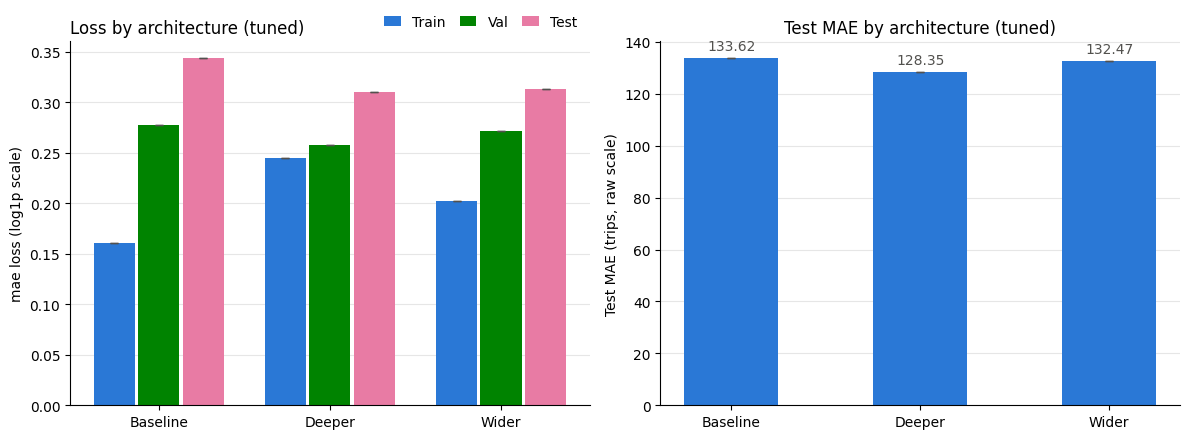

In [41]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Architecture Comparison  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# One figure over the three tuned architectures:
#   left  — train / val / test loss under the training criterion (mean ± std over seeds)
#   right — test-set MAE on the raw trip-count scale (mean ± std over seeds)
# Test loss is computed here with the same criterion as training, so the three
# bars per architecture are directly comparable (matching the overfitting-check
# in evaluate_models, which now also uses the training criterion).

import matplotlib.pyplot as plt

ARCH_RUNS = {
    "Baseline": (tuned_models,        tuned_train_losses,        tuned_val_losses),
    "Deeper":   (tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses),
    "Wider":    (tuned_wider_models,  tuned_wider_train_losses,  tuned_wider_val_losses),
}

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)
_y_target = y_test if IS_POISSON else np.log1p(y_test)   # test target on the training scale

def _test_loss_and_mae(model):
    """Per-seed test loss (training criterion) and raw-scale test MAE."""
    model.eval()
    with torch.no_grad():
        preds_raw = model(_X_test_t, _g_test_t).cpu().numpy().flatten()
    if config.LOSS == "mae":
        test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
    elif config.LOSS == "mse":
        test_loss = float(np.mean((preds_raw - _y_target) ** 2))
    elif config.LOSS == "poisson_nll":
        test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
    else:  # nb_nll — evaluate with the model's trained dispersion
        test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                      torch.as_tensor(_y_target, dtype=torch.float32),
                                      model.log_theta.detach().cpu()))
    preds = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    return test_loss, float(np.mean(np.abs(preds - y_test)))

stats = {}
for _label, (_models, _tr, _vl) in ARCH_RUNS.items():
    _per_seed = [_test_loss_and_mae(m) for m in _models]
    stats[_label] = {
        "train_loss": (np.mean(_tr), np.std(_tr)),
        "val_loss":   (np.mean(_vl), np.std(_vl)),
        "test_loss":  (np.mean([t for t, _ in _per_seed]), np.std([t for t, _ in _per_seed])),
        "mae":        (np.mean([m for _, m in _per_seed]), np.std([m for _, m in _per_seed])),
    }

summary_df = pd.DataFrame(
    {a: {k: f"{m:.4f} ± {s:.4f}" for k, (m, s) in d.items()} for a, d in stats.items()}
).T
print(f"Training criterion: {config.LOSS} ({'raw counts' if IS_POISSON else 'log1p scale'}), "
      f"{len(SEEDS)} seed(s)\n")
print(summary_df.to_string())

_archs  = list(stats)
_splits = [("train_loss", "Train", "#2a78d6"),
           ("val_loss",   "Val",   "#008300"),
           ("test_loss",  "Test",  "#e87ba4")]

fig, (ax_loss, ax_mae) = plt.subplots(1, 2, figsize=(12, 4.5))
_x = np.arange(len(_archs))

for _i, (_split, _sl, _c) in enumerate(_splits):
    _means = [stats[a][_split][0] for a in _archs]
    _stds  = [stats[a][_split][1] for a in _archs]
    ax_loss.bar(_x + (_i - 1) * 0.26, _means, width=0.24, color=_c, label=_sl,
                yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
ax_loss.set_xticks(_x, _archs)
ax_loss.set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
ax_loss.set_title("Loss by architecture (tuned)", loc="left")
ax_loss.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

_means = [stats[a]["mae"][0] for a in _archs]
_stds  = [stats[a]["mae"][1] for a in _archs]
ax_mae.bar(_x, _means, width=0.5, color="#2a78d6",
           yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
for _xi, _m, _s in zip(_x, _means, _stds):
    ax_mae.annotate(f"{_m:.2f}", (_xi, _m + _s), ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", color="#52514e")
ax_mae.set_xticks(_x, _archs)
ax_mae.set_ylabel("Test MAE (trips, raw scale)")
ax_mae.set_title("Test MAE by architecture (tuned)")

for _ax in (ax_loss, ax_mae):
    _ax.grid(axis="y", color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

plt.tight_layout()
plt.show()


### Learning Curves

Per-epoch train / validation / test loss for each tuned architecture, all under the training criterion. The dot marks the best-validation epoch whose weights early stopping restores. Requires re-running the tuned training cells once, since `train_model` now records the history on the returned models.


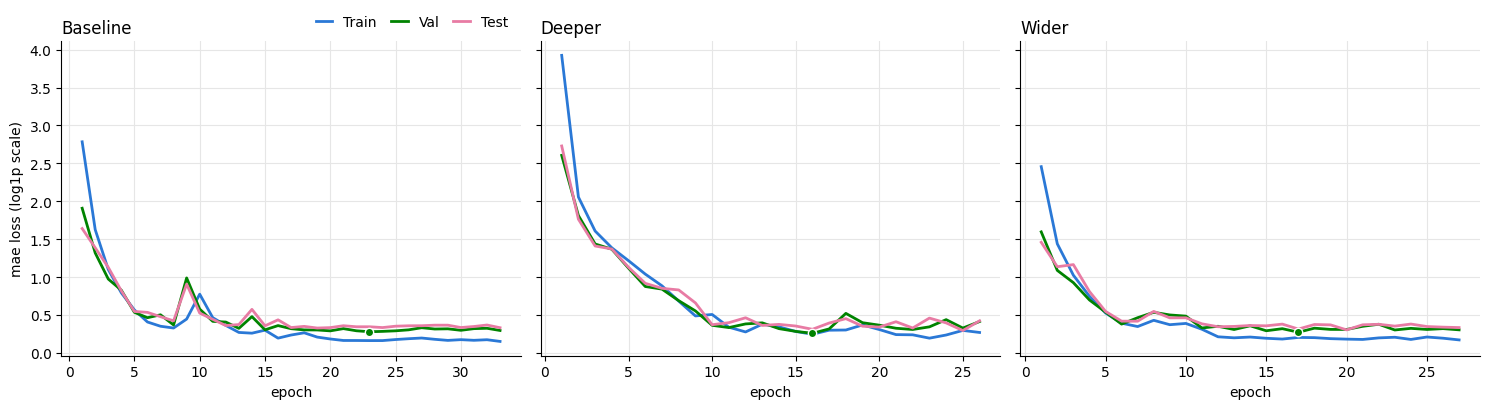

In [42]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Learning Curves          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Per-epoch train / val / test loss for the three tuned architectures.
# train_model records the history on each returned model; the tuned training
# cells pass test_data so the test curve is monitored per epoch too
# (monitoring only — it never influences training or model selection).

import matplotlib.pyplot as plt

ARCH_CURVES = {
    "Baseline": tuned_models,
    "Deeper":   tuned_deeper_models,
    "Wider":    tuned_wider_models,
}
_colors = {"train": "#2a78d6", "val": "#008300", "test": "#e87ba4"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for _ax, (_label, _models) in zip(axes, ARCH_CURVES.items()):
    for _si, _model in enumerate(_models):
        _h = getattr(_model, "history", None)
        if _h is None:
            raise RuntimeError("model has no training history — re-run the tuned "
                               "training cells (train_model records it now)")
        _epochs = np.arange(1, len(_h["train"]) + 1)
        for _split in ("train", "val", "test"):
            if _h[_split]:
                _ax.plot(_epochs, _h[_split], color=_colors[_split], lw=2,
                         alpha=1.0 if _si == 0 else 0.4,
                         label=_split.capitalize() if _si == 0 else None)
        _best = int(np.argmin(_h["val"]))   # epoch restored by early stopping
        _ax.plot(_best + 1, _h["val"][_best], "o", ms=6, color=_colors["val"],
                 markeredgecolor="white", zorder=3)
    _ax.set_title(_label, loc="left")
    _ax.set_xlabel("epoch")
    _ax.grid(color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

axes[0].set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
axes[0].legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.show()


### Statistical Significance — Wilcoxon Signed-Rank

Non-parametric paired test of whether each **tuned** network is more accurate than the benchmark models on the held-out test set, using per-row absolute errors (the tuned architectures are seed-ensembled — mean predicted count). Every model scores the same test rows, so the errors are paired. Reported with a Holm-corrected one-sided *p*-value (H1: NN error < benchmark error) and practical effect sizes, since on a test set this large even trivial gaps come out "significant".

This test aims to **identify whether a model adds value, not whether neural networks should be deployed**. If the difference in performance is not statistically significant, the model adds no measurable value over the benchmark. If it is significant, further analysis is needed to determine whether that value justifies the cost.

In [43]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Statistical Significance (Wilcoxon)     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #
#
# Wilcoxon signed-rank test: is each tuned NN more accurate than the benchmarks?
# Per-row absolute errors on the held-out test set; the tuned architectures are
# seed-ensembled (mean predicted count). Every model scores the same test rows,
# so the errors are paired. One-sided H1: NN abs-error < benchmark abs-error.
# p-values are Holm-corrected across all comparisons, and because a test set this
# large makes even trivial gaps "significant", the practical effect sizes
# (median abs-error reduction, share of rows the NN wins) are shown alongside.

from scipy.stats import wilcoxon

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(hex_test, dtype=torch.long).to(device)
_y        = np.asarray(y_test, dtype=float)


def _nn_ensemble_preds(models):
    """Seed-ensembled predicted counts (raw trip-count scale) on the test set."""
    acc = np.zeros(len(_y), dtype=float)
    for _m in models:
        _m.eval()
        with torch.no_grad():
            _pr = _m(_X_test_t, _g_test_t).cpu().numpy().flatten()
        acc += np.exp(_pr) if IS_POISSON else np.expm1(_pr)
    return acc / len(models)


nn_preds = {
    "Baseline (tuned)": _nn_ensemble_preds(tuned_models),
    "Deeper (tuned)":   _nn_ensemble_preds(tuned_deeper_models),
    "Wider (tuned)":    _nn_ensemble_preds(tuned_wider_models),
}
benchmark_preds = {
    "Historical mean": np.asarray(hist_mean_preds, dtype=float),
    "Ridge":           np.asarray(ridge_preds,     dtype=float),
}

_rows = []
for _mname, _mpred in nn_preds.items():
    _ae_nn = np.abs(_mpred - _y)
    for _bname, _bpred in benchmark_preds.items():
        _ae_bm = np.abs(_bpred - _y)
        _diff  = _ae_nn - _ae_bm
        _stat, _p = wilcoxon(_ae_nn, _ae_bm, alternative="less", zero_method="wilcox")
        _rows.append({
            "NN model"            : _mname,
            "Benchmark"           : _bname,
            "median AE (NN)"      : float(np.median(_ae_nn)),
            "median AE (bench)"   : float(np.median(_ae_bm)),
            "median AE reduction" : float(np.median(_ae_bm) - np.median(_ae_nn)),
            "NN wins %"           : float(100.0 * np.mean(_ae_nn < _ae_bm)),
            "W"                   : float(_stat),
            "p (one-sided)"       : float(_p),
            "n (non-tied)"        : int(np.sum(_diff != 0)),
        })

sig_df = pd.DataFrame(_rows)

# Holm-Bonferroni step-down correction across all comparisons
_pv  = sig_df["p (one-sided)"].to_numpy()
_ord = np.argsort(_pv)
_adj = np.empty_like(_pv)
_run = 0.0
for _rank, _idx in enumerate(_ord):
    _run = max(_run, (len(_pv) - _rank) * _pv[_idx])
    _adj[_idx] = min(_run, 1.0)
sig_df["p (Holm)"]    = _adj
sig_df["significant"] = sig_df["p (Holm)"] < 0.05

print("Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks")
print(f"paired over {len(_y):,} test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05\n")
with pd.option_context("display.width", 200, "display.max_columns", None,
                       "display.float_format", lambda v: f"{v:.4g}"):
    print(sig_df.to_string(index=False))


Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks
paired over 1,807 test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05

        NN model       Benchmark  median AE (NN)  median AE (bench)  median AE reduction  NN wins %         W  p (one-sided)  n (non-tied)   p (Holm)  significant
Baseline (tuned) Historical mean            16.7              22.22                5.523      61.26 6.403e+05      9.109e-16          1807  9.109e-16         True
Baseline (tuned)           Ridge            16.7              43.29                26.59      75.54 2.972e+05     1.317e-121          1807 5.269e-121         True
  Deeper (tuned) Historical mean           13.61              22.22                8.615       70.5 5.278e+05      4.328e-39          1807  1.188e-38         True
  Deeper (tuned)           Ridge           13.61              43.29                29.68      77.42 2.816e+05     7.179e-129          1807 3.589e-128         True
   Wider (tuned) Historical mean      